____
# Aberant values in SWOT 250m SLA



In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, U
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, prepared_wd, plot_exemple

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter', '0.5cpd', '1.5cpd', '2.5cpd', '3cpd']),
 dict_keys(['swot250naive', 'swot250gauss1e3', 'swot250gauss2e3', 'swot250gauss3e3', 'swot250gauss4e3', 'swot250gauss5e3', 'swot2kmnaive', 'swot2kmgauss1e3', 'swot2kmgauss2e3', 'swot2kmgauss3e3', 'swot2kmgauss4e3', 'swot2kmgauss5e3', 'swot2kmgauss1e4']),
 dict_keys(['era5']))

In [72]:
dfef = pd.read_csv(os.path.join(zarr_dir, 'editing_flags_250m.csv')).set_index('row_number')
dfc = pd.read_csv(ALTI['swot250naive'])[['row_number', 'cvl_distance_to_coast']].set_index('row_number')

dfa = pd.concat([dfef, dfc], axis=1)
dsa = dfa.to_xarray()

comb_list = [dict(drifter_key='nofilter', alti_key = 'swot250naive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),]

DS = dataset_coloc_combs(comb_list, nearest =False)
#DS = dataset_coloc_combs(comb_list, nearest =True)
DSS = DS.where(DS.depth==0, drop=True)
DSD = DS.where(DS.depth==15, drop=True)


#df = xr.merge([DSS.isel(id_comb=0), dsa]).to_dataframe()

nofilter__swot250naive_etaf__rio_0era5


__________________
# PB on synthetic figures

In [5]:
ds = compute_mean_square(DSD)/U2
df = ds.to_dataframe()
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e')
    synthetic_figure(df.loc[c], axs[1], dir='n')
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', c + '.png'))

NameError: name 'compute_mean_square' is not defined

__________________
# PB = Some aberant values considerably change the residual MS

- Where are these abusive values ? South of Minorca or south of the french coast
  
- Can they be related to :
    - SWOT ? yes for the 250m
    - editing flags ? No
    - distance to coast ? They are effectively near the coast
    - Are they visible on swot 250m product velocities ?

In [6]:
df = xr.merge([DS.isel(id_comb=0), dsa]).to_dataframe()
#df =df/np.sqrt(U2)

In [55]:
# SELECT OUTLIERS
a = 4e-4
dfpb = df.where((abs(df.sume)>a) | (abs(df.sumn)>a)).dropna()
len(dfpb)

df290 = dfpb.where(dfpb.drifter_id =='290')
df460 = dfpb.where(dfpb.drifter_id =='300534064300460')
df675 = dfpb.where(dfpb.drifter_id =='0-4388675')
dfggd = dfpb.where((abs(df.ggde)>a) | (abs(df.ggdn)>a)).dropna()

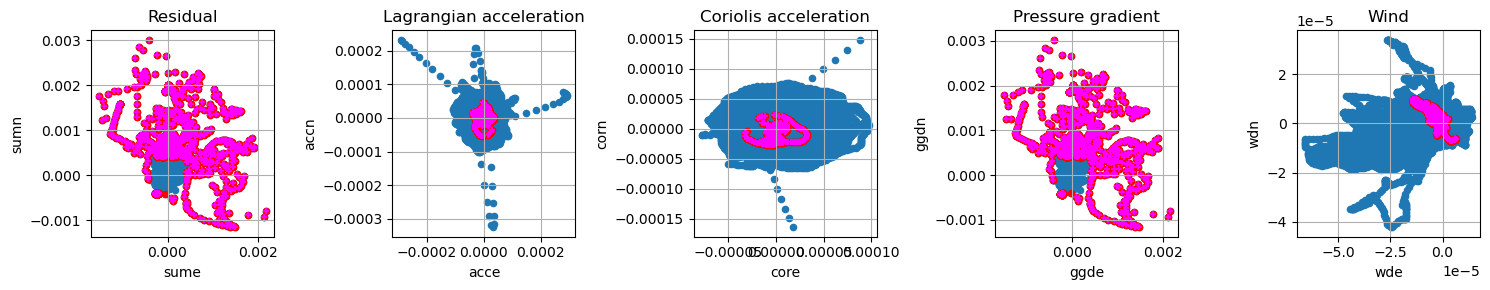

In [56]:
fig, axs = plt.subplots(1, 5, figsize=(15, 3))
axs = axs.flatten()
ax=axs[0]
df.plot.scatter('sume', 'sumn', ax=ax)
dfpb.plot.scatter('sume', 'sumn', ax=ax, c='r')
df290.plot.scatter('sume', 'sumn', ax=ax, c='g', marker='+')
df460.plot.scatter('sume', 'sumn', ax=ax, c='b', marker='+')
df675.plot.scatter('sume', 'sumn', ax=ax, c='orange', marker='+')
dfggd.plot.scatter('sume', 'sumn', ax=ax, c='magenta', marker='+')
ax.set_title('Residual')

ax=axs[1]
df.plot.scatter('acce', 'accn', ax=ax)
dfpb.plot.scatter('acce', 'accn', ax=ax, c='r')
df290.plot.scatter('acce', 'accn', ax=ax, c='g', marker='+')
df460.plot.scatter('acce', 'accn', ax=ax, c='b', marker='+')
df675.plot.scatter('acce', 'accn', ax=ax, c='orange', marker='+')
dfggd.plot.scatter('acce', 'accn', ax=ax, c='magenta', marker='+')
ax.set_title('Lagrangian acceleration')

ax=axs[2]
df.plot.scatter('core', 'corn', ax=ax)
dfpb.plot.scatter('core', 'corn', ax=ax, c='r')
df290.plot.scatter('core', 'corn', ax=ax, c='g', marker='+')
df460.plot.scatter('core', 'corn', ax=ax, c='b', marker='+')
df675.plot.scatter('core', 'corn', ax=ax, c='orange', marker='+')
dfggd.plot.scatter('core', 'corn', ax=ax, c='magenta', marker='+')
ax.set_title('Coriolis acceleration')

ax=axs[3]
df.plot.scatter('ggde', 'ggdn', ax=ax)
dfpb.plot.scatter('ggde', 'ggdn', ax=ax, c='r')
df290.plot.scatter('ggde', 'ggdn', ax=ax, c='g', marker='+')
df460.plot.scatter('ggde', 'ggdn', ax=ax, c='b', marker='+')
df675.plot.scatter('ggde', 'ggdn', ax=ax, c='orange', marker='+')
dfggd.plot.scatter('ggde', 'ggdn', ax=ax, c='magenta', marker='+')
ax.set_title('Pressure gradient')

ax=axs[4]
df.plot.scatter('wde', 'wdn', ax=ax)
dfpb.plot.scatter('wde', 'wdn', ax=ax, c='r')
df290.plot.scatter('wde', 'wdn', ax=ax, c='g', marker='+')
df460.plot.scatter('wde', 'wdn', ax=ax, c='b', marker='+')
df675.plot.scatter('wde', 'wdn', ax=ax, c='orange', marker='+')
dfggd.plot.scatter('wde', 'wdn', ax=ax, c='magenta', marker='+')
ax.set_title('Wind')


for ax in axs :
    ax.grid()

fig.tight_layout()


In [57]:
dfpb

,datetime,longitude,latitude,pass_number,time_to_swot,cycle_number,drifter_id,drifter_type,depth,phi,...,bad_quality_coast,ice,soft_outliers,extremes,mission_events,bad_swath_extremities,not_on_sea,no_data,gradient_nan,cvl_distance_to_coast
row_number,,,,,,,,,,,,,,,,,,,,,
72842.0,2023-04-27 23:40:00,6.026182,43.046144,3.0,0 days 04:01:01.002087232,504.0,300534062472380,SVP,50.0,1.825715,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3089.748829
72843.0,2023-04-27 23:50:00,6.025272,43.046565,3.0,0 days 04:11:01.002087232,504.0,300534062472380,SVP,50.0,1.825728,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3194.217088
72844.0,2023-04-28 00:00:00,6.024361,43.046967,3.0,0 days 04:21:01.002087232,504.0,300534062472380,SVP,50.0,1.825744,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3210.612073
72845.0,2023-04-28 00:10:00,6.023442,43.047348,3.0,0 days 04:31:01.002087232,504.0,300534062472380,SVP,50.0,1.825757,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3157.786655
72846.0,2023-04-28 00:20:00,6.022511,43.047706,3.0,0 days 04:41:01.002087232,504.0,300534062472380,SVP,50.0,1.825727,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3226.486739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201241.0,2023-05-27 14:00:00,4.101248,39.871715,3.0,0 days 00:57:52.993249728,534.0,4388589,CARTHE,0.0,1.797561,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,554.657599
201242.0,2023-05-27 14:10:00,4.101463,39.872015,3.0,0 days 00:47:52.993249728,534.0,4388589,CARTHE,0.0,1.797657,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,264.106633
201243.0,2023-05-27 14:20:00,4.101705,39.872352,3.0,0 days 00:37:52.993249728,534.0,4388589,CARTHE,0.0,1.797760,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,103.258981


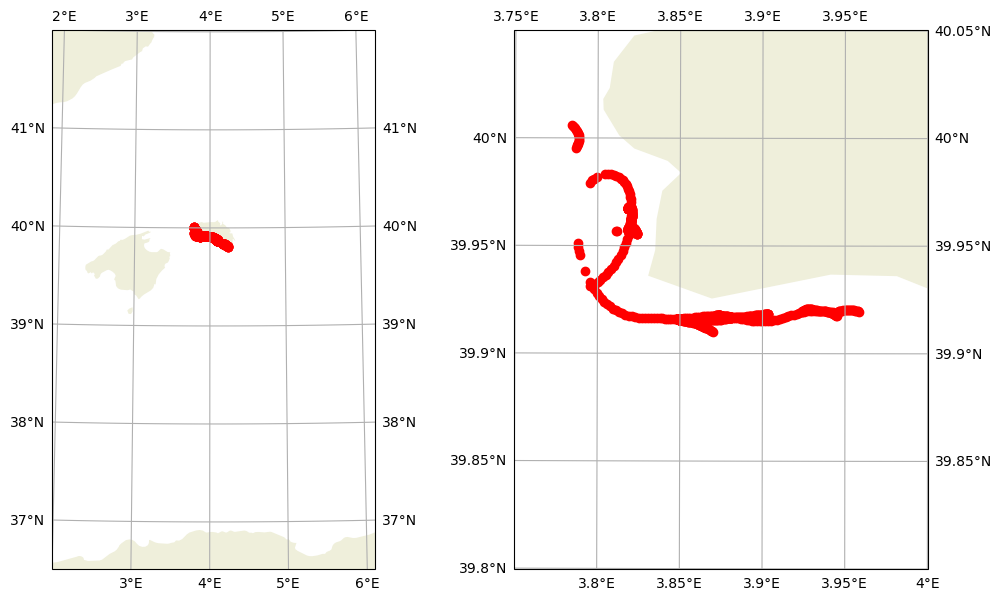

In [58]:
fig = plt.figure(figsize=(12,7), frameon=False)

ax = fig.add_subplot(121, projection=ccrs.Orthographic(dfpb.longitude.mean(), dfpb.latitude.mean()))
#a = dfc.plot.scatter('longitude', 'latitude',c='w10_era5', ax=ax, transform =crs, s=2)
bbox = [2, 6.1, 36.5, 42]
a = ax.scatter(dfpb.longitude, dfpb.latitude, transform =crs, c='r')
ax.set_extent(bbox)
ax.add_feature(cfeature.LAND,)

gl = ax.gridlines(draw_labels=True,)
gl.xlabels_top = False
gl.ylabels_right = False


ax = fig.add_subplot(122, projection=ccrs.Orthographic(dfpb.longitude.mean(), dfpb.latitude.mean()))
#a = dfc.plot.scatter('longitude', 'latitude',c='w10_era5', ax=ax, transform =crs, s=2)
bbox = [3.75, 4, 39.8, 40.05]
a = ax.scatter(dfpb.longitude, dfpb.latitude, transform =crs, c='r')
ax.set_extent(bbox)
ax.add_feature(cfeature.LAND,)

gl = ax.gridlines(draw_labels=True,)
gl.xlabels_top = False
gl.ylabels_right = False

In [59]:
idpb_swot = dfpb.drifter_id.unique()
tmin = [dfpb[(dfpb.drifter_id ==id_)].datetime.min() for id_ in idpb_swot]
tmax = [dfpb[(dfpb.drifter_id ==id_)].datetime.max() for id_ in idpb_swot]

In [60]:
i=0
dfpb[(dfpb.drifter_id ==idpb_swot[i]) & (dfpb.datetime>=tmin[i]) & (dfpb.datetime<=tmax[i])]

,datetime,longitude,latitude,pass_number,time_to_swot,cycle_number,drifter_id,drifter_type,depth,phi,...,bad_quality_coast,ice,soft_outliers,extremes,mission_events,bad_swath_extremities,not_on_sea,no_data,gradient_nan,cvl_distance_to_coast
row_number,,,,,,,,,,,,,,,,,,,,,
72842.0,2023-04-27 23:40:00,6.026182,43.046144,3.0,0 days 04:01:01.002087232,504.0,300534062472380,SVP,50.0,1.825715,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3089.748829
72843.0,2023-04-27 23:50:00,6.025272,43.046565,3.0,0 days 04:11:01.002087232,504.0,300534062472380,SVP,50.0,1.825728,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3194.217088
72844.0,2023-04-28 00:00:00,6.024361,43.046967,3.0,0 days 04:21:01.002087232,504.0,300534062472380,SVP,50.0,1.825744,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3210.612073
72845.0,2023-04-28 00:10:00,6.023442,43.047348,3.0,0 days 04:31:01.002087232,504.0,300534062472380,SVP,50.0,1.825757,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3157.786655
72846.0,2023-04-28 00:20:00,6.022511,43.047706,3.0,0 days 04:41:01.002087232,504.0,300534062472380,SVP,50.0,1.825727,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3226.486739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77098.0,2023-04-29 02:00:00,5.842575,43.030744,3.0,0 days 06:30:23.163436160,505.0,300534062472380,SVP,50.0,1.823524,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000.000000
77099.0,2023-04-29 02:10:00,5.841327,43.030748,3.0,0 days 06:40:23.163436160,505.0,300534062472380,SVP,50.0,1.823424,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1943.423002
77100.0,2023-04-29 02:20:00,5.840125,43.030753,3.0,0 days 06:50:23.163436160,505.0,300534062472380,SVP,50.0,1.823385,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2000.000000


In [61]:
df[(df.drifter_id ==idpb_swot[i]) & (df.datetime>=tmin[i]) & (df.datetime<=tmax[i]) ]

,datetime,longitude,latitude,pass_number,time_to_swot,cycle_number,drifter_id,drifter_type,depth,phi,...,bad_quality_coast,ice,soft_outliers,extremes,mission_events,bad_swath_extremities,not_on_sea,no_data,gradient_nan,cvl_distance_to_coast
row_number,,,,,,,,,,,,,,,,,,,,,
72842.0,2023-04-27 23:40:00,6.026182,43.046144,3.0,0 days 04:01:01.002087232,504.0,300534062472380,SVP,50.0,1.825715,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3089.748829
72843.0,2023-04-27 23:50:00,6.025272,43.046565,3.0,0 days 04:11:01.002087232,504.0,300534062472380,SVP,50.0,1.825728,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3194.217088
72844.0,2023-04-28 00:00:00,6.024361,43.046967,3.0,0 days 04:21:01.002087232,504.0,300534062472380,SVP,50.0,1.825744,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3210.612073
72845.0,2023-04-28 00:10:00,6.023442,43.047348,3.0,0 days 04:31:01.002087232,504.0,300534062472380,SVP,50.0,1.825757,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3157.786655
72846.0,2023-04-28 00:20:00,6.022511,43.047706,3.0,0 days 04:41:01.002087232,504.0,300534062472380,SVP,50.0,1.825727,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3226.486739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77098.0,2023-04-29 02:00:00,5.842575,43.030744,3.0,0 days 06:30:23.163436160,505.0,300534062472380,SVP,50.0,1.823524,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000.000000
77099.0,2023-04-29 02:10:00,5.841327,43.030748,3.0,0 days 06:40:23.163436160,505.0,300534062472380,SVP,50.0,1.823424,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1943.423002
77100.0,2023-04-29 02:20:00,5.840125,43.030753,3.0,0 days 06:50:23.163436160,505.0,300534062472380,SVP,50.0,1.823385,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2000.000000


In [69]:
def remove_pb_swot(df):
    for i in range(len(idpbswot)):
        pb = (df.drifter_id ==idpbswot[i]) & (df.datetime>=tmin[i]) & (df.datetime<=tmax[i])
        df = df[~pb]
        return df
dfr = remove_pb_swot(df)    

In [71]:
df

,datetime,longitude,latitude,pass_number,time_to_swot,cycle_number,drifter_id,drifter_type,depth,phi,...,bad_quality_coast,ice,soft_outliers,extremes,mission_events,bad_swath_extremities,not_on_sea,no_data,gradient_nan,cvl_distance_to_coast
row_number,,,,,,,,,,,,,,,,,,,,,
0.0,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32897.636451
1.0,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33000.000000
2.0,2023-04-02 02:10:00,5.241153,42.895152,3.0,0 days 02:27:27.303464,478.0,0-4388554,CARTHE,0.0,1.815553,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,33000.000000
3.0,2023-04-02 02:20:00,5.238567,42.893930,3.0,0 days 02:37:27.303464,478.0,0-4388554,CARTHE,0.0,1.815624,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,33000.000000
4.0,2023-04-02 02:30:00,5.235922,42.892675,3.0,0 days 02:47:27.303464,478.0,0-4388554,CARTHE,0.0,1.815523,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33006.934949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405568.0,2023-07-10 06:10:00,1.809666,39.312590,16.0,0 days 11:13:38.131544384,577.0,300534060211000,SVP,15.0,-1.801372,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30000.000000
405569.0,2023-07-10 06:20:00,1.809406,39.312064,16.0,0 days 11:23:38.131544384,577.0,300534060211000,SVP,15.0,-1.801418,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30000.000000
405570.0,2023-07-10 06:30:00,1.809097,39.311556,16.0,0 days 11:33:38.131544384,577.0,300534060211000,SVP,15.0,-1.801475,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30000.000000


In [70]:
dfr

,datetime,longitude,latitude,pass_number,time_to_swot,cycle_number,drifter_id,drifter_type,depth,phi,...,bad_quality_coast,ice,soft_outliers,extremes,mission_events,bad_swath_extremities,not_on_sea,no_data,gradient_nan,cvl_distance_to_coast
row_number,,,,,,,,,,,,,,,,,,,,,
0.0,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32897.636451
1.0,NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33000.000000
2.0,2023-04-02 02:10:00,5.241153,42.895152,3.0,0 days 02:27:27.303464,478.0,0-4388554,CARTHE,0.0,1.815553,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,33000.000000
3.0,2023-04-02 02:20:00,5.238567,42.893930,3.0,0 days 02:37:27.303464,478.0,0-4388554,CARTHE,0.0,1.815624,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,33000.000000
4.0,2023-04-02 02:30:00,5.235922,42.892675,3.0,0 days 02:47:27.303464,478.0,0-4388554,CARTHE,0.0,1.815523,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33006.934949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405568.0,2023-07-10 06:10:00,1.809666,39.312590,16.0,0 days 11:13:38.131544384,577.0,300534060211000,SVP,15.0,-1.801372,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30000.000000
405569.0,2023-07-10 06:20:00,1.809406,39.312064,16.0,0 days 11:23:38.131544384,577.0,300534060211000,SVP,15.0,-1.801418,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30000.000000
405570.0,2023-07-10 06:30:00,1.809097,39.311556,16.0,0 days 11:33:38.131544384,577.0,300534060211000,SVP,15.0,-1.801475,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30000.000000


In [67]:
[np.array([True, False, True])np.array([True, False, False])]

array([2, 0, 1])

In [36]:
tmin, tmax

([Timestamp('2023-04-09 11:40:00'),
  Timestamp('2023-04-27 23:20:00'),
  Timestamp('2023-05-05 02:30:00'),
  Timestamp('2023-05-20 00:20:00'),
  Timestamp('2023-05-24 13:30:00')],
 [Timestamp('2023-04-09 12:10:00'),
  Timestamp('2023-04-29 10:30:00'),
  Timestamp('2023-05-25 03:10:00'),
  Timestamp('2023-05-20 00:40:00'),
  Timestamp('2023-05-27 14:40:00')])

In [35]:
i=4
dfpb[(dfpb.drifter_id ==idpb_swot[i]) & (dfpb.datetime>=tmin[i]) & (dfpb.datetime<=tmax[i]) ]

,datetime,longitude,latitude,pass_number,time_to_swot,cycle_number,drifter_id,drifter_type,depth,phi,...,bad_quality_coast,ice,soft_outliers,extremes,mission_events,bad_swath_extremities,not_on_sea,no_data,gradient_nan,cvl_distance_to_coast
row_number,,,,,,,,,,,,,,,,,,,,,
194006.0,2023-05-24 13:30:00,4.241887,39.807417,3.0,0 days 01:55:59.365211712,531.0,4388589,CARTHE,0.0,1.798820,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,786.735742
194007.0,2023-05-24 13:40:00,4.240256,39.808103,3.0,0 days 01:45:59.365211712,531.0,4388589,CARTHE,0.0,1.798789,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,476.038376
194008.0,2023-05-24 13:50:00,4.238611,39.808857,3.0,0 days 01:35:59.365211712,531.0,4388589,CARTHE,0.0,1.798752,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,88.034096
194009.0,2023-05-24 14:00:00,4.236947,39.809676,3.0,0 days 01:25:59.365211712,531.0,4388589,CARTHE,0.0,1.798995,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,83.249148
194010.0,2023-05-24 14:10:00,4.235258,39.810557,3.0,0 days 01:15:59.365211712,531.0,4388589,CARTHE,0.0,1.799068,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,156.200743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201241.0,2023-05-27 14:00:00,4.101248,39.871715,3.0,0 days 00:57:52.993249728,534.0,4388589,CARTHE,0.0,1.797561,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,554.657599
201242.0,2023-05-27 14:10:00,4.101463,39.872015,3.0,0 days 00:47:52.993249728,534.0,4388589,CARTHE,0.0,1.797657,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,264.106633
201243.0,2023-05-27 14:20:00,4.101705,39.872352,3.0,0 days 00:37:52.993249728,534.0,4388589,CARTHE,0.0,1.797760,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,103.258981


In [35]:
i=4
dfpb[(dfpb.drifter_id ==idpb_swot[i]) & (dfpb.datetime>=tmin[i]) & (dfpb.datetime<=tmax[i]) ]

,datetime,longitude,latitude,pass_number,time_to_swot,cycle_number,drifter_id,drifter_type,depth,phi,...,bad_quality_coast,ice,soft_outliers,extremes,mission_events,bad_swath_extremities,not_on_sea,no_data,gradient_nan,cvl_distance_to_coast
row_number,,,,,,,,,,,,,,,,,,,,,
194006.0,2023-05-24 13:30:00,4.241887,39.807417,3.0,0 days 01:55:59.365211712,531.0,4388589,CARTHE,0.0,1.798820,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,786.735742
194007.0,2023-05-24 13:40:00,4.240256,39.808103,3.0,0 days 01:45:59.365211712,531.0,4388589,CARTHE,0.0,1.798789,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,476.038376
194008.0,2023-05-24 13:50:00,4.238611,39.808857,3.0,0 days 01:35:59.365211712,531.0,4388589,CARTHE,0.0,1.798752,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,88.034096
194009.0,2023-05-24 14:00:00,4.236947,39.809676,3.0,0 days 01:25:59.365211712,531.0,4388589,CARTHE,0.0,1.798995,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,83.249148
194010.0,2023-05-24 14:10:00,4.235258,39.810557,3.0,0 days 01:15:59.365211712,531.0,4388589,CARTHE,0.0,1.799068,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,156.200743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201241.0,2023-05-27 14:00:00,4.101248,39.871715,3.0,0 days 00:57:52.993249728,534.0,4388589,CARTHE,0.0,1.797561,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,554.657599
201242.0,2023-05-27 14:10:00,4.101463,39.872015,3.0,0 days 00:47:52.993249728,534.0,4388589,CARTHE,0.0,1.797657,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,264.106633
201243.0,2023-05-27 14:20:00,4.101705,39.872352,3.0,0 days 00:37:52.993249728,534.0,4388589,CARTHE,0.0,1.797760,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,103.258981


In [ ]:
err_swot = [np.arange(14980, 14984)] 
+[np.arange(72840, 72889)] 
+[np.arange(77009,  77112)]
+[np.arange(81509,81527)]
+[np.arange(104605, 104626)]
+[np.arange(117628,117761)]
+[np.arange(125439,125582)]
+[np.arange(131438, 131580)]
+[np.arange(136258, 136400)]
+[np.arange(145922, 146064)]
+[np.arange(150862, 151004)]
+[np.arange(150862, 151004)]

In [13]:
list(dfpb.index)

[14980.0,
 14981.0,
 14982.0,
 14983.0,
 72840.0,
 72841.0,
 72842.0,
 72843.0,
 72844.0,
 72845.0,
 72846.0,
 72847.0,
 72848.0,
 72849.0,
 72850.0,
 72851.0,
 72852.0,
 72853.0,
 72854.0,
 72855.0,
 72856.0,
 72857.0,
 72858.0,
 72859.0,
 72860.0,
 72861.0,
 72862.0,
 72863.0,
 72864.0,
 72865.0,
 72866.0,
 72867.0,
 72868.0,
 72869.0,
 72870.0,
 72885.0,
 72886.0,
 72887.0,
 72888.0,
 72889.0,
 77009.0,
 77010.0,
 77011.0,
 77012.0,
 77013.0,
 77014.0,
 77015.0,
 77016.0,
 77017.0,
 77018.0,
 77019.0,
 77020.0,
 77021.0,
 77022.0,
 77023.0,
 77024.0,
 77025.0,
 77026.0,
 77027.0,
 77028.0,
 77029.0,
 77030.0,
 77031.0,
 77032.0,
 77033.0,
 77034.0,
 77035.0,
 77036.0,
 77037.0,
 77038.0,
 77039.0,
 77040.0,
 77041.0,
 77042.0,
 77043.0,
 77044.0,
 77045.0,
 77046.0,
 77047.0,
 77048.0,
 77049.0,
 77050.0,
 77051.0,
 77052.0,
 77053.0,
 77054.0,
 77055.0,
 77056.0,
 77057.0,
 77058.0,
 77059.0,
 77060.0,
 77061.0,
 77062.0,
 77063.0,
 77064.0,
 77065.0,
 77066.0,
 77067.0,
 77068.0,


In [10]:
#fig = plt.subplots(figsize =(10, 7)) 
#xbins = np.arange(-3e-3, 3e-3, 5e-2)
#ybins = np.arange(-2e-3, 2e-3, 5e-2)
#df_ = df[['sume', 'sumn']].dropna()
#plt.hist2d(df_["sume"], df_["sumn"], bins =(100, 100)) 
#plt.title("Simple 2D Histogram")  
#plt.show()

# Check for SWOT outliers
## Visualization figures

In [22]:
from diagnosis import select_nearest_swot_coloc
dfpb_ = select_nearest_swot_coloc(dfpb)

In [9]:
from diagnosis import select_nearest_swot_coloc
dfpb_ = select_nearest_swot_coloc(dfpb)
index_pb = list(dfpb_.index)

for rn in index_pb :
    plot_exemple(rn,df, 'swot250_outliers')

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails wh

Error in callback <function _draw_all_if_interactive at 0x1705620e0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x19231b760> (for post_execute), with arguments args (),kwargs {}:



KeyboardInterrupt



# Are these outliers in SWOT 2km ? NO


In [10]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0')]

DS2km = dataset_coloc_combs(comb_list, nearest =False)

nofilter__swot2kmnaive_etaf__rio_0era5


In [11]:
df2km = DS2km.isel(id_comb=0).to_dataframe()
df2kmpb = df2km.take(dfpb.index)

from diagnosis import select_nearest_swot_coloc
df2kmpb_ = select_nearest_swot_coloc(df2kmpb)
index_2kmpb = list(df2kmpb_.index)

for rn in index_pb :
    try :
        plot_exemple(rn, df2km, 'swot250outliers_on2km', swot_product='2km')
    except :
        continue

In [12]:
l = [l for l in list(dfpb.index) if l in list(df2km.index)]
df2km.loc[l]

,datetime,longitude,latitude,pass_number,time_to_swot,cycle_number,drifter_id,drifter_type,depth,sume,...,excn_ggd,wdn,excn_wd,prodn_acc_cor,prodn_acc_ggd,prodn_acc_wd,prodn_cor_ggd,prodn_cor_wd,prodn_ggd_wd,id_comb
row_number,,,,,,,,,,,,,,,,,,,,,


_______________
# Différence entre les colocs 250m et 2km 

In [40]:
len(df), len(df2km)

(383263, 290395)

In [43]:
df_all = df.merge(df2km[['pass_number','longitude', 'latitude']].drop_duplicates(),# on=['col1','col2'], 
                   how='left', indicator=True)

In [44]:
def select_row(df, pass_number, cycle_number, drifter_id):
    return df.where((df.pass_number==pass_number)&(df.cycle_number==cycle_number)&(df.drifter_id==drifter_id)).dropna()

In [81]:
select_row(df2km, 3, 522., '300534062474750')

,datetime,longitude,latitude,pass_number,time_to_swot,cycle_number,drifter_id,drifter_type,depth,sume,...,excn_ggd,wdn,excn_wd,prodn_acc_cor,prodn_acc_ggd,prodn_acc_wd,prodn_cor_ggd,prodn_cor_wd,prodn_ggd_wd,id_comb
row_number,,,,,,,,,,,,,,,,,,,,,


In [45]:
dfonly = df_all[ df_all._merge =='left_only']
dfonly_ = select_nearest_swot_coloc(dfonly)
len(dfonly), len(dfonly_)

(93240, 1266)

In [16]:
len(dfonly_)

17

In [47]:
df_all

,datetime,longitude,latitude,pass_number,time_to_swot,cycle_number,drifter_id,drifter_type,depth,sume,...,ice,soft_outliers,extremes,mission_events,bad_swath_extremities,not_on_sea,no_data,gradient_nan,cvl_distance_to_coast,_merge
0,2023-04-01 11:50:00,4.811970,42.220893,3.0,0 days 11:52:32.696536,478.0,300534060315840,SVP,15.0,-0.000002,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,114000.000000,both
1,2023-04-01 12:00:00,4.812432,42.221430,3.0,0 days 11:42:32.696536,478.0,300534060315840,SVP,15.0,-0.000004,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,113940.490247,both
2,2023-04-01 12:10:00,4.812916,42.221930,3.0,0 days 11:32:32.696536,478.0,300534060315840,SVP,15.0,-0.000006,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,113920.969919,both
3,2023-04-01 12:20:00,4.813418,42.222394,3.0,0 days 11:22:32.696536,478.0,300534060315840,SVP,15.0,-0.000009,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,113758.848724,both
4,2023-04-01 12:30:00,4.813933,42.222825,3.0,0 days 11:12:32.696536,478.0,300534060315840,SVP,15.0,-0.000009,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,113572.617334,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383258,2023-07-10 06:10:00,2.417785,39.788394,16.0,0 days 11:13:38.131544384,577.0,300534060015760,SVP,15.0,0.000015,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13063.591430,both
383259,2023-07-10 06:20:00,2.416881,39.788885,16.0,0 days 11:23:38.131544384,577.0,300534060015760,SVP,15.0,0.000018,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13245.561986,both
383260,2023-07-10 06:30:00,2.415948,39.789399,16.0,0 days 11:33:38.131544384,577.0,300534060015760,SVP,15.0,0.000019,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13765.739505,both
383261,2023-07-10 06:40:00,2.414994,39.789938,16.0,0 days 11:43:38.131544384,577.0,300534060015760,SVP,15.0,0.000020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,13973.404159,both


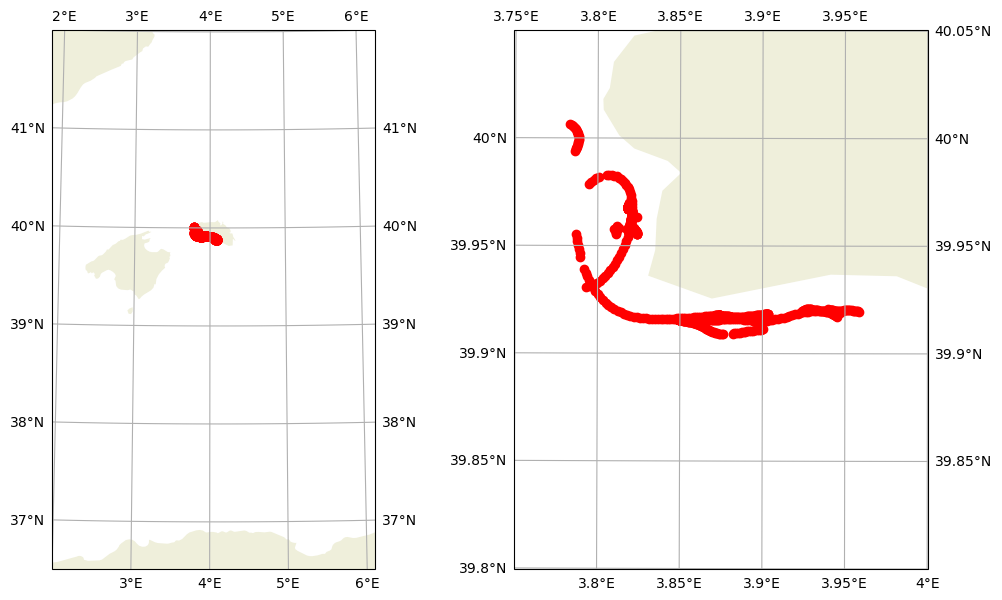

In [7]:
fig = plt.figure(figsize=(12,7), frameon=False)

ax = fig.add_subplot(121, projection=ccrs.Orthographic(dfpb.longitude.mean(), dfpb.latitude.mean()))
#a = dfc.plot.scatter('longitude', 'latitude',c='w10_era5', ax=ax, transform =crs, s=2)
bbox = [2, 6.1, 36.5, 42]
a = ax.scatter(dfpb.longitude, dfpb.latitude, transform =crs, c='r')
ax.set_extent(bbox)
ax.add_feature(cfeature.LAND,)

gl = ax.gridlines(draw_labels=True,)
gl.xlabels_top = False
gl.ylabels_right = False


ax = fig.add_subplot(122, projection=ccrs.Orthographic(dfpb.longitude.mean(), dfpb.latitude.mean()))
#a = dfc.plot.scatter('longitude', 'latitude',c='w10_era5', ax=ax, transform =crs, s=2)
bbox = [3.75, 4, 39.8, 40.05]
a = ax.scatter(dfpb.longitude, dfpb.latitude, transform =crs, c='r')
ax.set_extent(bbox)
ax.add_feature(cfeature.LAND,)

gl = ax.gridlines(draw_labels=True,)
gl.xlabels_top = False
gl.ylabels_right = False